Mounted at /content/drive
Clases: ['Maduro', 'Pasado', 'Verde']
Usando: cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 357MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch [1/15] | Train Loss: 1.0818 | Val Loss: 1.0397 | Val Acc: 33.33%
Epoch [2/15] | Train Loss: 1.0071 | Val Loss: 1.0561 | Val Acc: 33.33%
Epoch [3/15] | Train Loss: 0.9193 | Val Loss: 1.0674 | Val Acc: 33.33%
Epoch [4/15] | Train Loss: 0.9109 | Val Loss: 1.0640 | Val Acc: 33.33%
Epoch [5/15] | Train Loss: 0.7880 | Val Loss: 1.0455 | Val Acc: 33.33%
Epoch [6/15] | Train Loss: 0.7505 | Val Loss: 1.0135 | Val Acc: 33.33%
Epoch [7/15] | Train Loss: 0.7324 | Val Loss: 0.9831 | Val Acc: 33.33%
Epoch [8/15] | Train Loss: 0.7076 | Val Loss: 0.9490 | Val Acc: 33.33%
Epoch [9/15] | Train Loss: 0.6370 | Val Loss: 0.9097 | Val Acc: 50.00%
Epoch [10/15] | Train Loss: 0.5835 | Val Loss: 0.8750 | Val Acc: 50.00%
Epoch [11/15] | Train Loss: 0.4721 | Val Loss: 0.8423 | Val Acc: 66.67%
Epoch [12/15] | Train Loss: 0.5043 | Val Loss: 0.8139 | Val Acc: 83.33%
Epoch [13/15] | Train Loss: 0.5269 | Val Loss: 0.7884 | Val Acc: 83.33%
Epoch [14/15] | Train Loss: 0.4611 | Val Loss: 0.7652 | Val Acc: 83.33%
E

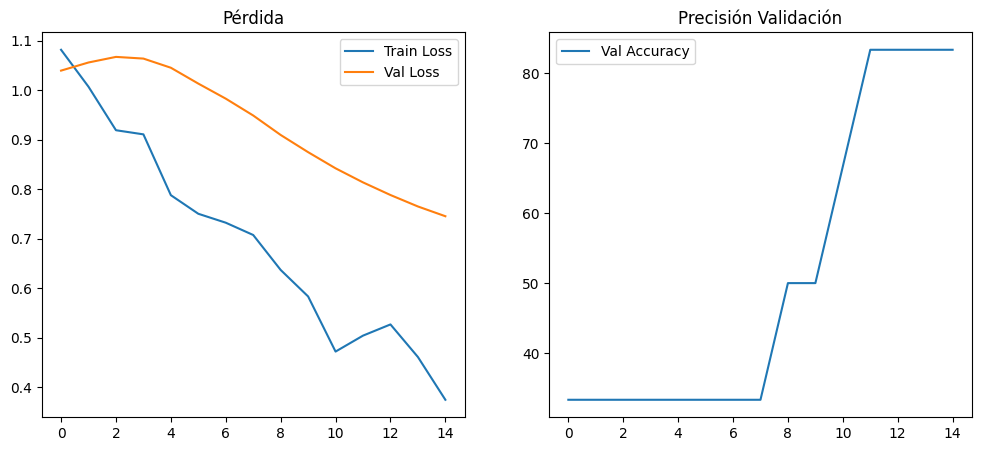

Modelo guardado correctamente
Resultado: Maduro


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install torch torchvision matplotlib
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from PIL import Image
import matplotlib.pyplot as plt

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(
        brightness=0.5,
        contrast=0.5,
        saturation=0.6,
        hue=0.1
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomPerspective(distortion_scale=0.4, p=0.6),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset_path = "/content/drive/MyDrive/papaya_dataset"

full_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=train_transform
)

print("Clases:", full_dataset.classes)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size]
)

val_dataset.dataset.transform = val_transform

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando:", device)

model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 3)
)

for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.0003,
    weight_decay=1e-4
)

epochs = 15

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_losses.append(train_loss)

    model.eval()
    correct = 0
    total = 0
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    val_losses.append(val_loss)
    val_accuracies.append(accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {accuracy:.2f}%"
    )
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Pérdida")
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_accuracies, label="Val Accuracy")
plt.title("Precisión Validación")
plt.legend()

plt.show()

torch.save(model.state_dict(), "papaya_madurez_model.pth")
print("Modelo guardado correctamente")

test_image_path = "/content/drive/MyDrive/papaya_dataset/test_papaya.jpg"

image = Image.open(test_image_path).convert("RGB")
image = val_transform(image).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(image)
    _, pred = torch.max(output, 1)

print("Resultado:", full_dataset.classes[pred.item()])
